# 02. 실적 · 애널리스트 · 뉴스 (계획 7~8단계)

모든 분석의 질문은 하나임: **이 정보가 프리마켓 갭에 이미 반영되어 있는가, 아니면 갭에 없는 정보를 더 주는가.**
그래서 항상 "갭 크기가 같은 조건"에서 비교함.

뉴스 집계는 첫 실행에 약 30초 걸리고 이후엔 캐시를 씀.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import eda_utils as U

U.setup_plot()
pd.set_option("display.float_format", "{:.4f}".format)

panel, cal = U.load_all(reddit=False)
d = panel.dropna(subset=["gap"]).copy()
d["gap_q"] = pd.qcut(d["abs_gap"], 5, labels=["1 작음", "2", "3", "4", "5 큼"])

## 1. 실적

### 그림: 상자 그림 (box plot)
상자 그림은 집단의 분포를 상자(25%~75%), 가운데 선(중앙값), 수염(대부분의 범위)으로 요약한 그림임.
실적 반영일과 나머지 날의 |수익률|과 |갭| 분포를 나란히 비교함.

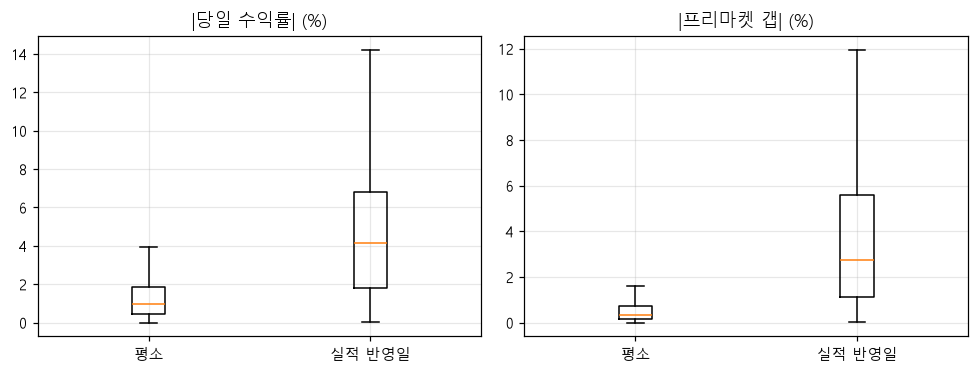

,n,M,abs_gap
earn,,,
0.0000,25614,0.1483,0.0062
1.0000,409,0.6528,0.0395


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, col, title in [(axes[0], "ret_pct", "|당일 수익률| (%)"), (axes[1], "gap_pct", "|프리마켓 갭| (%)")]:
    ax.boxplot([d.loc[d["earn"] == 0, col].abs(), d.loc[d["earn"] == 1, col].abs()],
               tick_labels=["평소", "실적 반영일"], showfliers=False)
    ax.set(title=title)
plt.tight_layout()
plt.show()
d.groupby("earn").agg(n=("M", "size"), M=("M", "mean"), abs_gap=("abs_gap", "mean"))

### 갭 크기가 같아도 실적이 급등락을 더 설명하는가
### 그림: 묶음 막대그래프 (grouped bar chart)
묶음 막대그래프는 **가로축 범주마다 두 개 이상의 막대를 나란히 세워 집단끼리 비교하는 그림**임.
여기서 범주는 |갭| 오분위, 두 막대는 평소와 실적 반영일임. 같은 갭 크기 안에서 실적일 막대가 더 높으면
실적이 갭 외에 추가 정보를 준다는 뜻임.

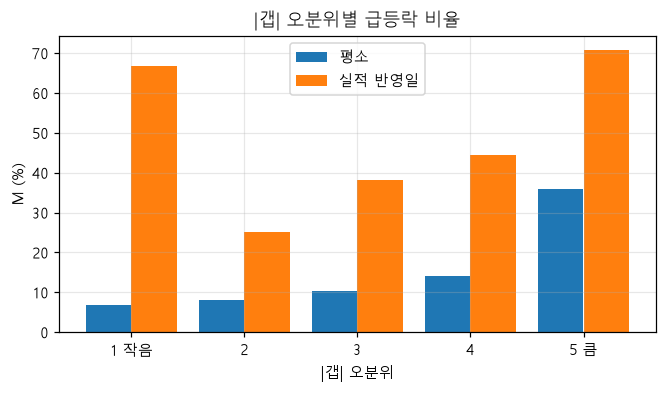

earn,평소 n,실적일 n
gap_q,,
1 작음,5199,6
2,5196,8
3,5184,21
4,5159,45
5 큼,4876,329


In [3]:
pv = d.pivot_table(index="gap_q", columns="earn", values="M", aggfunc="mean", observed=True) * 100
cnt = d.pivot_table(index="gap_q", columns="earn", values="M", aggfunc="size", observed=True)
x = np.arange(len(pv))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(x - 0.2, pv[0], 0.4, label="평소")
ax.bar(x + 0.2, pv[1], 0.4, label="실적 반영일")
ax.set_xticks(x, pv.index)
ax.set(title="|갭| 오분위별 급등락 비율", xlabel="|갭| 오분위", ylabel="M (%)")
ax.legend()
plt.show()
cnt.rename(columns={0: "평소 n", 1: "실적일 n"})

### 서프라이즈 부호와 갭 부호가 엇갈릴 때
예: EPS는 예상보다 좋았는데(+) 갭은 음수. 시장이 숫자 외의 가이던스 등을 나쁘게 본 경우일 수 있음.
이때 갭 이후 움직임(rest)이 어느 쪽으로 가는지 봄.

In [4]:
e = d[d["earn"] == 1].assign(gap_sign=np.sign(d["gap"]))
e.groupby(["surp_sign", "gap_sign"]).agg(n=("ret_t", "size"), ret_mean=("ret_t", "mean"),
                                         rest_mean=("rest", "mean"), M=("M", "mean"))

n  ret_mean  rest_mean      M
surp_sign gap_sign                                 
-1.0000   -1.0000    29   -0.0475    -0.0106 0.6552
          1.0000     13    0.0718     0.0088 0.6154
0.0000    -1.0000    12   -0.0625    -0.0097 0.6667
          1.0000      1    0.0097    -0.0025 0.0000
1.0000    -1.0000   152   -0.0354    -0.0008 0.6316
          1.0000    201    0.0442     0.0026 0.6716

## 2. 애널리스트

등급 상향·하향이 있었던 날의 당일 수익률과 갭 이후 움직임을 봄.
갭에 이미 반영됐다면 ret_t는 움직여도 rest는 0 근처여야 함.

In [5]:
a = d.assign(event=np.select([d["an_up"] > 0, d["an_down"] > 0], ["상향", "하향"], "없음"))
a.groupby("event").agg(n=("ret_t", "size"), ret_mean=("ret_t", "mean"), gap_mean=("gap", "mean"),
                       rest_mean=("rest", "mean"), M=("M", "mean"))

,n,ret_mean,gap_mean,rest_mean,M
event,,,,,
상향,245,0.0072,0.0032,0.0037,0.1959
없음,25611,0.0010,0.0007,0.0001,0.1557
하향,167,0.0016,-0.0006,0.0019,0.1796


## 3. 뉴스

### 중복 제거
같은 제목(정규화 후)의 기사가 같은 대상일에 여러 번 들어온 것을 하나로 셈.
아래 가로 막대그래프는 종목별로 중복 제거 후 남은 비율임. 낮을수록 재전송·신디케이션이 많은 것임.

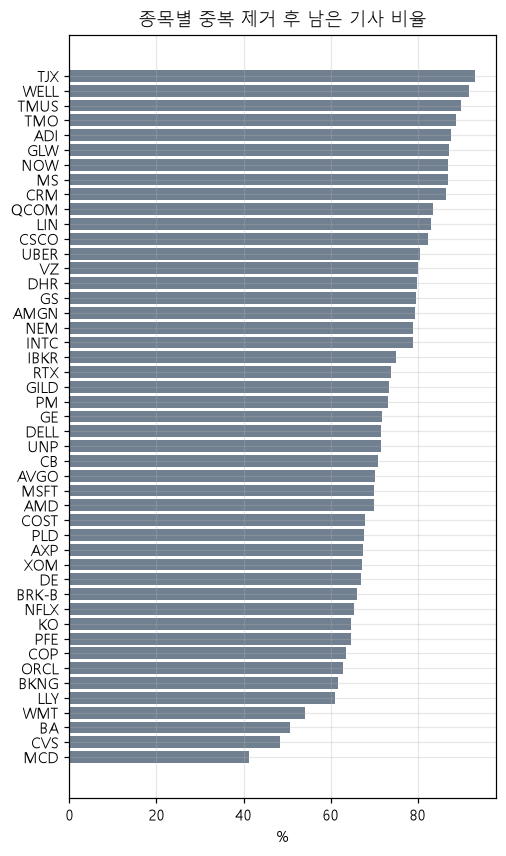

기사가 한 건도 없는 종목: ['AMZN', 'JNJ', 'V']


In [6]:
news = pd.read_parquet(U.CACHE / "news.parquet")
r = news.groupby("symbol")[["news_n", "news_raw"]].sum()
r = (r["news_n"] / r["news_raw"]).sort_values()
fig, ax = plt.subplots(figsize=(5, 9))
ax.barh(r.index, r * 100, color="slategray")
ax.set(title="종목별 중복 제거 후 남은 기사 비율", xlabel="%")
plt.show()
print("기사가 한 건도 없는 종목:", sorted(set(panel["symbol"]) - set(news["symbol"])))

### 비정상 관심도
news_n_abn = log(1 + 오늘 건수) − log(1 + 직전 20일 EMA). 0보다 크면 평소보다 기사가 많은 날임.
종목마다 기사량 수준이 수십 배 달라서 건수 자체가 아니라 **평소 대비 비율**로 봄.

아래는 구간별 평균 막대그래프(binned bar chart)임. 왼쪽은 관심도 십분위별 급등락 비율,
오른쪽은 같은 것을 |갭|이 작은 날(하위 60%)만 따로 본 것임. 갭이 작은데도 관심도가 급등락을 가르면 갭에 없는 정보임.

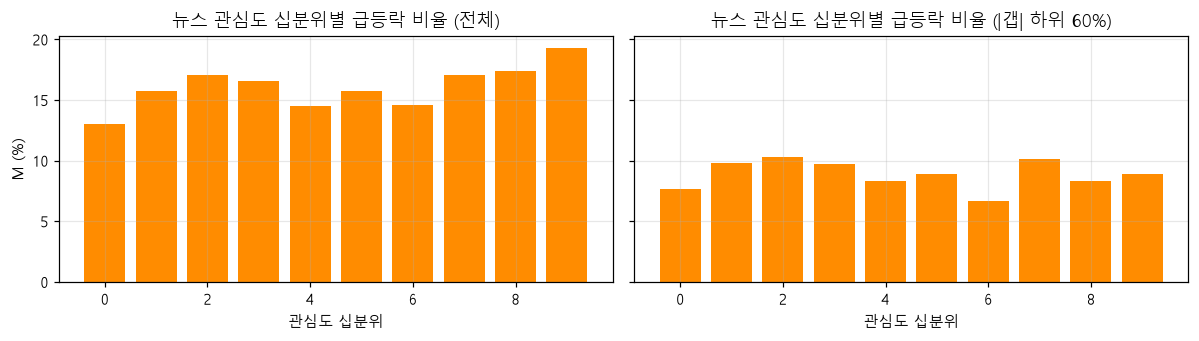

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, sub, title in [(axes[0], d, "전체"), (axes[1], d[d["gap_q"].isin(["1 작음", "2", "3"])], "|갭| 하위 60%")]:
    b = U.binned(sub, "news_n_abn", "M", q=10)
    ax.bar(range(len(b)), b["M"] * 100, color="darkorange")
    ax.set(title=f"뉴스 관심도 십분위별 급등락 비율 ({title})", xlabel="관심도 십분위")
axes[0].set_ylabel("M (%)")
plt.tight_layout()
plt.show()

### 논조(tone)와 방향
tone 평균·최솟값·극단 음수 건수를 십분위로 나눠 상승일 비율과 갭 이후 움직임(rest)을 봄.
급등락은 평균적인 뉴스보다 극단적인 기사 몇 건이 만드는 경우가 많아 꼬리값도 같이 봄.

In [8]:
rows = []
for col in ["tone_mean", "tone_min", "tone_max", "tone_neg_tail"]:
    b = U.binned(d.assign(up=(d["D"] > 0).astype(float)), col, ["up", "rest", "M"], q=5)
    rows.append(b.assign(feature=col).set_index(["feature", "bin"]))
pd.concat(rows)[["n", "up", "rest", "M"]]

n     up    rest      M
feature       bin                                                       
tone_mean     (-7.651000000000001, -0.0392]   4435 0.5139  0.0001 0.1504
              (-0.0392, 0.626]                4435 0.5335  0.0006 0.1732
              (0.626, 1.122]                  4435 0.5136 -0.0002 0.1804
              (1.122, 1.744]                  4435 0.5172 -0.0003 0.1802
              (1.744, 13.333]                 4435 0.5204  0.0001 0.1599
tone_min      (-31.251, -8.067]               4435 0.5220  0.0002 0.1617
              (-8.067, -5.333]                4439 0.5134 -0.0001 0.1827
              (-5.333, -3.304]                4432 0.5239  0.0003 0.1674
              (-3.304, -1.342]                4436 0.5257  0.0000 0.1801
              (-1.342, 13.333]                4433 0.5136  0.0000 0.1520
tone_max      (-7.651000000000001, 3.466]     4435 0.5154 -0.0001 0.1396
              (3.466, 5.03]                   4436 0.5239  0.0004 0.1567
              (5.03, 6.557]                   4446 0.5220  0.0001 0.1790
              (6.557, 8.6]                    4423 0.5146 -0.0001 0.1838
              (8.6, 27.553]                   4435 0.5227  0.0002 0.1849
tone_neg_tail (-0.001, 1.0]                  15738 0.5217  0.0001 0.1681
              (1.0, 3.0]                      2326 0.5009 -0.0002 0.1642
              (3.0, 703.0]                    4111 0.5227  0.0002 0.1742

## 4. 빠른 Δscore 확인 (한 구간)

정식 비교는 04 노트북에서 여러 검증 분할로 함. 여기서는 대상일 2026-01-01 기준 한 번만 나눠 방향을 봄.

In [9]:
base = ["gap_pct", "abs_gap", "zgap", "gap_rank"]
groups = {"실적": ["earn", "surp_sign", "surp_abs", "surp_pct_w"],
          "애널리스트": ["an_n", "an_up", "an_down", "an_tgt_chg"],
          "뉴스": ["news_n_abn", "tone_mean", "tone_min", "tone_max", "tone_std", "tone_neg_tail", "tone_pos_tail"]}
split = [("2026-01 기준", (panel["target"] < "2025-12-15").to_numpy(), (panel["target"] >= "2026-01-01").to_numpy())]
U.delta_table(panel, base, groups, split)

,split,group,solo,with_base,base,d_score,flip_rate,big_recall,big_prec
0,2026-01 기준,기준선,0.5101,0.5101,0.5101,0.0000,0.1781,0.5873,0.2720
1,2026-01 기준,실적,0.0040,0.5122,0.5101,0.0021,0.1875,0.6037,0.2613
2,2026-01 기준,애널리스트,0.0020,0.5064,0.5101,-0.0037,0.1865,0.5829,0.2740
3,2026-01 기준,뉴스,-0.0071,0.5081,0.5101,-0.0021,0.1614,0.5675,0.2850
